МОСКОВСКИЙ ГОСУДАРСТВЕННЫЙ ТЕХНИЧЕСКИЙ УНИВЕРСИТЕТ
им. Н.Э. Баумана

Факультет “Информатика и системы управления”
Кафедра “Системы обработки информации и управления”

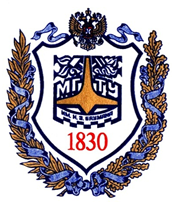

Дисциплина “Системное программирование”

Отчёт по лабораторной работе №4. Вариант №18
“Арифметические вычисления”

Выполнил:
Студент группы ИУ5-35Б
Сергучанов Т.Н.
Преподаватель:
Аксенова М.В
Артамонов Ю.Н.

Москва 2026


# Задание:
2. Написать программу, которая для заданного n вычисляет сумму:
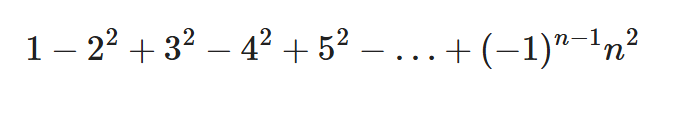

3. Написать программу, которая для заданного n вычисляет сумму:
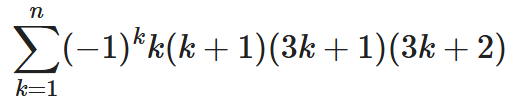


11 Команда из n судей принимает решение большинством голосов. Каждый судья должен проголосовать, ответив "Да" (1), или "Нет" (0). Реализовать программу, которая помогает судьям принять окончательное решение.


# Код программы пункта 2.

In [ ]:
format ELF64

public _start

section ".data" writeable
    number db ?, ?, ?       '''переменная для ввода n. Переменная для вывода суммы (sum)'''
    sum db ?, ?, ?

section ".text" executable
_start:
    mov rax, 0
    mov rdi, 0
    mov rsi, number         '''считали n через системный вызов read'''
    mov rdx, 3
    syscall

    mov rbx, 10
    movzx eax, [number]     '''обработали десятки n, расшифровали и записали в r12'''
    sub eax, 48
    mul rbx

    mov r12, rax

    movzx eax, [number+1]
    sub eax, 48
                           '''обработали единицы n и также добавили в r12, тем самым собрав число n'''
    add r12, rax

    mov r13, -1            '''r13 - отрицательная единица, как по формуле, r14 - счётчик n, r15 - промежуточный результат возведения -1 в степень, r9 - подсчёт итоговой суммы'''
    mov r14, 1
    mov r15, 1
    mov r9, 0

    sum_loop:
        mov r10, r14       '''r10 - хранит результат возведения n в квадрат, как по формуле'''
        imul r10, r14
        mov rbx, r14
        sub rbx, 1         '''созраняем текущий счётчик n в rbx и вычитаем единицу, как следует по формуле'''
        multiplier:
            cmp rbx, 0
            je zero_found  '''проверка, необходимая, для случая, когда текущая n равна 1. 1-1 = 0, а значит (-1)^0 = 1. По причине этого r15 не изменяется и
                              мы переходим во внешний цикл подсчёта произведения и суммы'''

            imul r15, r13  '''если проверка не сработала, значит текущая n больше единицы и выполняется внутренний цикл возведения степени:
                              умножаем r15 на r13 до тех пор, пока rbx не равен нулю'''

            sub rbx, 1
            cmp rbx, 0
            jnz multiplier

        zero_found:
            imul r15, r10  '''проводим итоговое произведение: возведённую единицу в текущую степень на n^2'''
            add r9, r15    '''добавляем результат в итоговую сумму, зачищаем r15, увеличиваем текущую n на единицу'''
            mov r15, 1
            add r14, 1     '''внешний цикл будет работать до тех пор, пока счётчик n(r14) не равен введённой пользователем n(r12)'''
            cmp r14, r12
            jle sum_loop

    minus:
        cmp r9, 0          '''если итоговая сумма больше нуля, значит она положительная и мы перепрыгиваем в блок обработки положительного числа'''
        jge plus

        mov eax, r9d       '''если же проверка не сработала, значит сумма - отрицательное число. Копируем его в регистр eax'''
        mov [sum], 45      '''добавляем в переменную суммы ASCII-код знака "минус"'''
        neg eax            '''меняем знак суммы на противоположный'''

        mov edx, 0
        mov ecx, 10
        div ecx            '''делим сумму на 10, благодаря этому десятки оказываются в eax, а единицы в edx'''
        add eax, 48        '''превращаем десятки и единицы в их ASCII-коды'''
        add edx, 48
        mov [sum+1], al    '''записываем коды десятков и единиц в переменную суммы'''
        mov [sum+2], dl

        jmp exit_programm  '''без условия перепрыгиваем на блок вывода и завершения программы,
                            так как после обработки сценария с отрицательной суммой блок с положительным числом нам уже не нужен'''

    plus:
        mov eax, r9d       '''сюда процессор перепрыгивает, если сумма оказалась положительным числом.
                            Он работает точно также, как и блок с отрицательным числом, кроме того, что мы не добавляем знак минуса в переменную суммы'''
        mov edx, 0
        mov ecx, 10
        div ecx
        add eax, 48
        add edx, 48
        mov [sum], al
        mov [sum+1], dl

    exit_programm:
        mov rax, 1
        mov rdi, 1       '''выводим сумму на экран'''
        mov rsi, sum
        mov rdx, 3
        syscall

        mov rax, 60
        mov rdi, 0       '''завершаем программу'''
        syscall


# Скриншот работы программы пункта 2 и калькулятора для проверки:
## 1. При n = 4
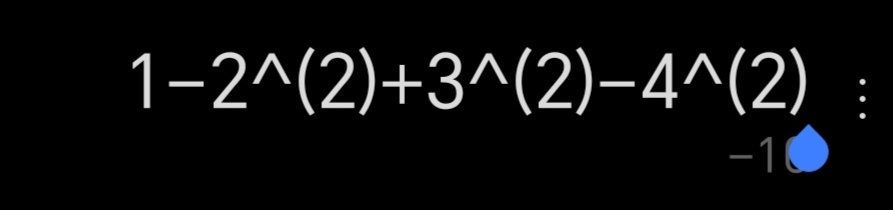

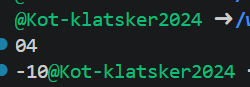

## 2. При n = 5
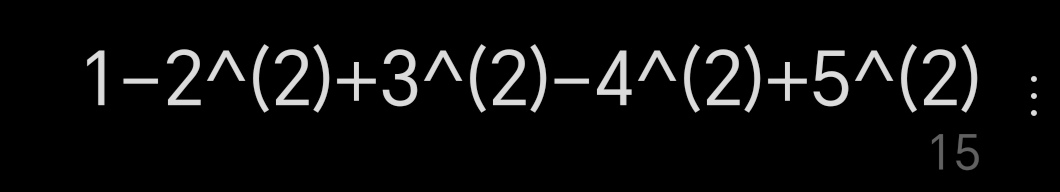

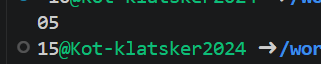

# Код программы пункта 3.

In [ ]:
format ELF64

public _start

section ".data" writeable
    number db ?, ?, ?
    sum db ?, ?, ?

section ".text" executable
_start:
    mov rax, 0
    mov rdi, 0                  '''считываем n, расшифровываем и записываем в r12'''
    mov rsi, number
    mov rdx, 3
    syscall

    mov rbx, 10
    movzx eax, [number]
    sub eax, 48
    mul rbx

    mov r12, rax

    movzx eax, [number+1]
    sub eax, 48

    add r12, rax

    mov r14, 1
    mov r15, 1
    mov r13, -1
    mov r9, 0

    sum_loop:
        mov rbx, r14
        multiplier:
            imul r15, r13

            sub rbx, 1          '''возводим отрицательную единицу в текущую степень'''
            cmp rbx, 0
            jnz multiplier

        mov r10, r14            '''r10 хранит результат первой скобки формулы - k(k+1)'''
        add r10, 1
        imul r10, r14
        mov r11, 1              '''r11 хранит результат второй скобки формулы - (3k+1)'''
        imul r11, r14, 3
        add r11, 1
        mov r8, 1
        imul r8, r14, 3         '''r8 хранит результат последней скобки формулы - (3k+2)'''
        add r8, 2

        imul r15, r10           '''умножаем результат возведения отрицательной единицы в текущую степень на каждую скобку'''
        imul r15, r11
        imul r15, r8

        add r9, r15
        mov r15, 1              '''записываем результат в сумму (r9), зачищаем r15(промежуточный результат возведения единицы в отрицательной степень), увеличиваем счётчик текущей n на 1
                                цикл работает до тех пор, пока r14 не равен r12'''
        add r14, 1
        cmp r14, r12
        jle sum_loop

                                '''блок обработки отрицательной и положительной суммы, вывода суммы абсолютно эдентичен коду из предыдущего пункта'''

    minus:
        cmp r9, 0
        jge plus

        mov eax, r9d
        mov [sum], 45
        neg eax

        mov edx, 0
        mov ecx, 10
        div ecx
        add eax, 48
        add edx, 48
        mov [sum+1], al
        mov [sum+2], dl

        jmp exit_programm

    plus:
        mov eax, r9d
        mov edx, 0
        mov ecx, 10
        div ecx
        add eax, 48
        add edx, 48
        mov [sum], al
        mov [sum+1], dl

    exit_programm:
        mov rax, 1
        mov rdi, 1
        mov rsi, sum
        mov rdx, 3
        syscall

        mov rax, 60
        mov rdi, 0              '''завершение программы'''
        syscall


# Скриншот работы программы пункта 3 и калькулятора для проверки:
## 1. При n = 1

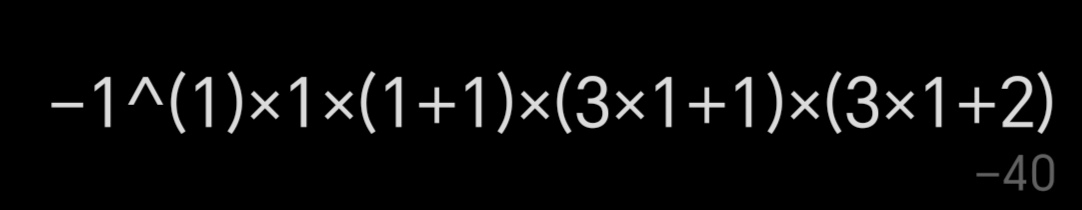

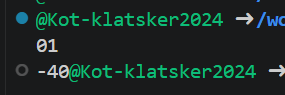

# Код программы пункта 11.

In [ ]:
format ELF64

public _start

section ".data" writeable
    number db ?, ?, ?            '''переменная для обработки количества судей n'''
    answer db ?, ?               '''переменная для обработка ответа судьи: да(1)/нет(0)'''
    all_answer db ?, ?, ?, ?     '''переменная для вывода заключительного ответа'''
    endl db 0xA

section ".text" executable
_start:
    mov rax, 0
    mov rdi, 0
    mov rsi, number              '''обработка числа n, расшифровываем и записываем его в r12'''
    mov rdx, 3
    syscall

    mov rbx, 10
    movzx eax, [number]
    sub eax, 48
    mul rbx

    mov r12, rax

    movzx eax, [number+1]
    sub eax, 48

    add r12, rax

    mov r13, 0                     '''r13 - счётчик ответов Нет. r14 - счётчик ответов Да'''
    mov r14, 0

    poll:
        mov rax, 0
        mov rdi, 0
        mov rsi, answer            '''обработка ответа текущего судьи, расшифровываем его и записываем в r15'''
        mov rdx, 2
        syscall

        movzx eax, [answer]
        sub eax, 48

        mov r15, rax

        cmp r15, 0                '''если текущий ответ это нет, то есть r15 равен нулю, срабатывает джампер на блок обработки ответов Нет.
                                  Если r15 равен 1, значит текущий судья ответил Да и срабатывает джампер на обработку ответов Да'''
        je NO

        cmp r15, 1
        je YES

    jmp exit_programm           '''если ответ текущего судьи введён некорректно, программа безопасно завершается'''

    NO:
        add r13, 1              '''пополняем счётчик отрицательных ответов и уменьшаем количество судей на 1, если r12 не равен нулю, то есть остались ещё непрголосвавшие судьи,
                                срабатываем джампер и процессор вновь попадает в блок обработки ответов судей'''
        sub r12, 1
        jnz poll

    jmp calculations            '''если голос последнего судьи будет отрицательным, то мы пропускаем блок обработки положительных ответов и попадаем в блок финальных подсчётов'''

    YES:
        add r14, 1              '''пополняем счётчик положительных ответов и уменьшаем количество судей на 1, если r12 не равен нулю, то есть остались ещё непрголосвавшие судьи,
                                срабатывает джампер и процессор вновь попадает в блок обработки и расшифровки ответов'''
        sub r12, 1
        jnz poll

    calculations:
        cmp r13, r14            '''сравниваем количества отрицательных и положительных ответов. Если отрицательных больше, выведет NO, ели положительных - YES, если количества ответов равны, выведет NONE'''
        ja all_NO
        jb all_YES
        je NONE

    all_NO:
        mov [all_answer], 78   '''записываем ASCII-коды букв в переменную заключительного ответа: 78 - N, 79 - O и прыгаем в блок вывода и завершения программы'''
        mov [all_answer+1], 79
        jmp exit_programm

    all_YES:
        mov [all_answer], 89   '''записываем ASCII-коды букв в переменную заключительного ответа: 89 - Y, 69 - E, 83 - S и прыгаем в блок вывода и завершения программы'''
        mov [all_answer+1], 69
        mov [all_answer+2], 83
        jmp exit_programm

    NONE:
        mov [all_answer], 78   '''записываем ASCII-коды букв в переменную заключительного ответа'''
        mov [all_answer+1], 79
        mov [all_answer+2], 78
        mov [all_answer+3], 69

    exit_programm:
        mov rax, 1
        mov rdi, 1
        mov rsi, all_answer     '''вывод ответа'''
        mov rdx, 4
        syscall

        mov rax, 1
        mov rdi, 1
        mov rsi, endl          '''вывод переноса страны для красоты'''
        mov rdx, 1
        syscall

        mov rax, 60
        mov rdi, 0             '''завершение программы'''
        syscall


# Скриншот работы программы пункта 11:
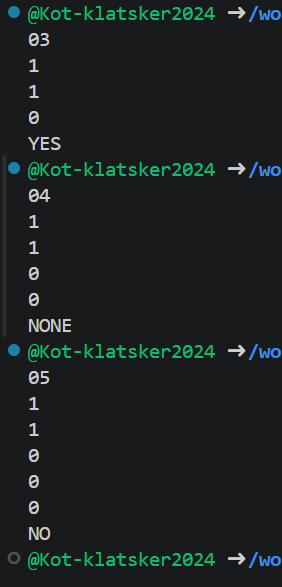